# **Weather Analytics: Predictive Modeling and Statistical Analysis of Meteorological Patterns**

**Project Overview**

This comprehensive data science project explores a rich meteorological dataset containing 899 weather observations from diverse global locations. The analysis systematically examines weather patterns through statistical methods and machine learning techniques to uncover relationships between atmospheric variables and predict weather conditions. From temperature-humidity correlations to precipitation forecasting, this project implements a full-stack analytical workflow—beginning with exploratory data analysis and hypothesis testing, progressing through dimensionality reduction and statistical modeling, and culminating in a suite of machine learning algorithms for both classification and regression tasks. The work demonstrates how modern data science can transform raw weather measurements into actionable insights about climate behavior and predictive capabilities.

# **Lets started.........**

In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('C:\\Users\\rakib\\Downloads\\weather_dataset.csv')

In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature_C,8000.0,16.124156,14.938509,-24.9500,9.02750,15.59000,25.42000,49.9900
Feels_Like_C,8000.0,16.968238,19.168331,-35.0000,4.67750,14.83000,29.70000,55.0000
Humidity_Percent,8000.0,65.002713,25.525907,0.0000,42.70000,70.70000,87.90000,100.0000
Dew_Point_C,8000.0,4.677140,12.117110,-40.0000,-1.05000,5.28000,11.36000,34.5100
Pressure_hPa,8000.0,1008.368035,17.592706,950.0000,999.55000,1009.57000,1019.00000,1049.9400
Wind_Speed_mps,8000.0,29.336010,14.528011,0.5000,15.00000,40.00000,40.00000,40.0000
Wind_Direction_deg,8000.0,180.327713,103.865247,0.0000,89.47500,181.55000,270.82500,360.0000
Precipitation_mm,8000.0,4.595071,9.886000,0.0000,0.00000,0.00000,5.00000,80.0000
Cloud_Cover_Percent,8000.0,66.515388,29.419343,0.0000,46.27500,78.20000,89.50000,100.0000
Visibility_km,8000.0,10.630287,5.644066,0.0000,6.42000,10.62500,14.78000,20.0000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Temperature_C        8000 non-null   float64
 1   Feels_Like_C         8000 non-null   float64
 2   Humidity_Percent     8000 non-null   float64
 3   Dew_Point_C          8000 non-null   float64
 4   Pressure_hPa         8000 non-null   float64
 5   Wind_Speed_mps       8000 non-null   float64
 6   Wind_Direction_deg   8000 non-null   float64
 7   Precipitation_mm     8000 non-null   float64
 8   Cloud_Cover_Percent  8000 non-null   float64
 9   Visibility_km        8000 non-null   float64
 10  UV_Index             8000 non-null   float64
 11  Latitude             8000 non-null   float64
 12  Longitude            8000 non-null   float64
 13  Weather_Class        8000 non-null   object 
dtypes: float64(13), object(1)
memory usage: 875.1+ KB


In [5]:
df.value_counts()

Temperature_C  Feels_Like_C  Humidity_Percent  Dew_Point_C  Pressure_hPa  Wind_Speed_mps  Wind_Direction_deg  Precipitation_mm  Cloud_Cover_Percent  Visibility_km  UV_Index  Latitude  Longitude  Weather_Class
-24.95         -29.62        45.8              -33.23       1020.96       9.34            221.1               0.00              35.1                 18.46          4.0       -42.6483   28.5776   Cold             1
-24.92         -30.25        34.0              -36.18       1006.83       10.67           260.5               0.00              51.2                 11.31          1.4        40.6349  -29.7931   Cold             1
-24.82         -30.56        60.0              -30.31       1039.30       11.47           18.1                0.00              66.5                 18.26          3.1        34.3831   175.7858  Cold             1
-24.80         -25.80        42.2              -33.91       1026.60       2.00            88.1                0.00              32.5                 

In [6]:
df.isnull().sum()

Temperature_C          0
Feels_Like_C           0
Humidity_Percent       0
Dew_Point_C            0
Pressure_hPa           0
Wind_Speed_mps         0
Wind_Direction_deg     0
Precipitation_mm       0
Cloud_Cover_Percent    0
Visibility_km          0
UV_Index               0
Latitude               0
Longitude              0
Weather_Class          0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

# **Basic Analysis**

**What is the average Wind_Speed_mps for rows where Weather_Class is 'Cloudy'?**

In [8]:
cloudy_rows = df[df['Weather_Class']=='Cloudy']
avg_wind_speed_cloudy=cloudy_rows['Wind_Speed_mps'].mean()
avg_wind_speed_cloudy

np.float64(38.87436666666667)

**Count the number of occurrences for each Weather_Class (e.g., how many 'Rainy' days?).**

In [9]:
weather_counts = df['Weather_Class'].value_counts()
for weather, count in weather_counts.items():
    print(f'{weather}: {count}')
print(f'Total: {weather_counts.sum()}')

Cloudy: 1200
Clear: 960
Rainy: 800
Humid: 720
Stormy: 640
Heatwave: 560
Drizzle: 560
Thunderstorm: 480
Hot: 480
Foggy: 480
Dusty: 400
Cold: 400
Snowy: 320
Total: 8000


**Sort the dataset by UV_Index in descending order and display the top 10 rows.**

In [10]:
sorted_df = df.sort_values(by= 'UV_Index', ascending=False)
top_10 = sorted_df.head(10)
print('Top 10 rows with highest UV index:')
print('='*80)
print(top_10.to_string())
print("\n"+'='*80)
print(f'Highest UV index is: {top_10["UV_Index"].iloc[0]:.1f}')
print(f'Lowest UV index is: {top_10["UV_Index"].iloc[-1]:.1f}')


Top 10 rows with highest UV index:
      Temperature_C  Feels_Like_C  Humidity_Percent  Dew_Point_C  Pressure_hPa  Wind_Speed_mps  Wind_Direction_deg  Precipitation_mm  Cloud_Cover_Percent  Visibility_km  UV_Index  Latitude  Longitude Weather_Class
1145          34.82         36.82              16.9        -0.81       1018.25           40.00               310.6              0.00                 42.3          12.14      15.0   21.2191   -15.5011           Hot
7477          49.98         50.85              61.4        -0.17       1019.14           40.00               211.9              0.00                 54.9          20.00      15.0   31.0377    21.5649      Heatwave
1919          40.72         42.72              16.1         9.55       1027.68           40.00               198.1              0.00                 38.7          16.46      15.0   34.3007  -170.8399           Hot
5077          49.73         41.75              40.7        -1.86       1022.59           40.00               

# **Data Analysis and Visualization**

**Compute the correlation between Temperature_C and Humidity_Percent. Is there a strong relationship?**

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

correlation= df['Temperature_C'].corr(df['Humidity_Percent'])

print(f'Correlation coefficient: {correlation:.2f}')

#interpreting the correlation
if correlation > 0:
    strength = 'Strong'
elif abs(correlation) > 0.3:
    strength = 'Moderate'
else:
    strength = 'Weak'

if correlation > 0:
    direction = 'positive'
elif correlation < 0:
    direction = 'negative'
else:
    direction = 'no'


print('\n')
print(f'Temperature range: {df["Temperature_C"].min():.1f}C to {df["Temperature_C"].max():.1f}C')
print(f'Humidity range: {df["Humidity_Percent"].min():.1f}% to {df["Humidity_Percent"].max():.1f}%')
print(f'There is a {strength} {direction} correlation between Temperature and Humidity.')
print(f'Mean Temperature: {df['Temperature_C'].mean():.1f}C')
print(f'Mean Humidity: {df['Humidity_Percent'].mean():.1f}%')

Correlation coefficient: -0.13


Temperature range: -24.9C to 50.0C
Humidity range: 0.0% to 100.0%
There is a Weak negative correlation between Temperature and Humidity.
Mean Temperature: 16.1C
Mean Humidity: 65.0%


C:\Users\rakib\AppData\Local\Temp\ipykernel_8700\2001647239.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


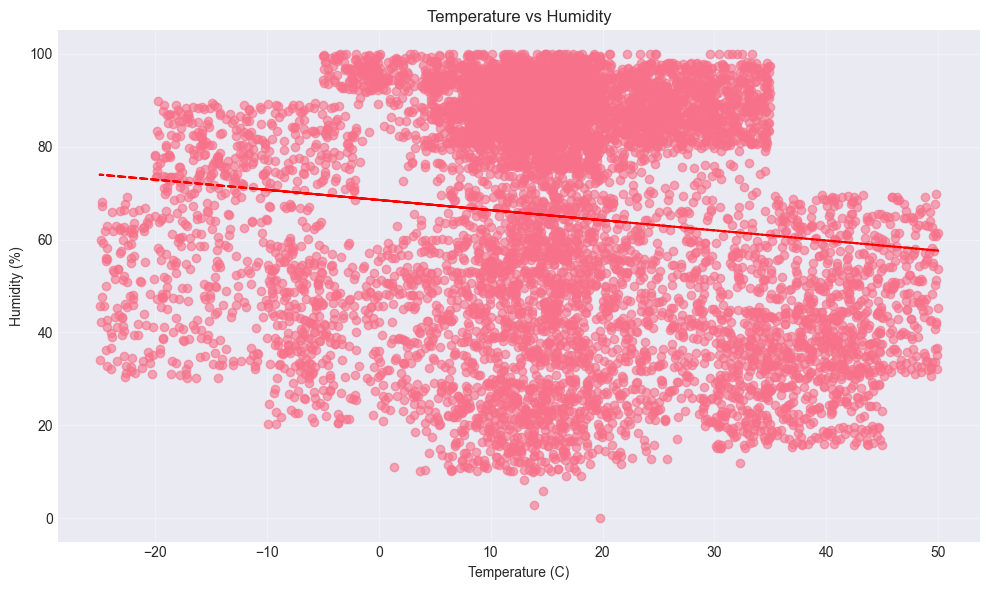

In [12]:
plt.figure(figsize=(10,6))
plt.scatter(df['Temperature_C'], df['Humidity_Percent'], alpha=0.6)
plt.title('Temperature vs Humidity')
plt.xlabel('Temperature (C)')
plt.ylabel('Humidity (%)')
plt.grid(True, alpha= 0.3)

z= np.polyfit(df['Temperature_C'], df['Humidity_Percent'],1)
p= np.poly1d(z)
plt.plot(df['Temperature_C'], p(df['Temperature_C']),"r--")
plt.legend()
plt.tight_layout()
plt.show()

**Group the data by Weather_Class and calculate the average Dew_Point_C for each group.**

In [13]:
avg_dew_point_by_class = df.groupby('Weather_Class')['Dew_Point_C'].mean().sort_values(ascending=False)
for weather_class, avg_dew in avg_dew_point_by_class.items():
    print(f'{weather_class:15}: {avg_dew:.2f}C')

Humid          : 26.52C
Foggy          : 7.49C
Rainy          : 5.61C
Stormy         : 5.52C
Heatwave       : 5.35C
Cloudy         : 5.35C
Hot            : 5.26C
Dusty          : 5.14C
Thunderstorm   : 5.11C
Drizzle        : 5.06C
Clear          : 1.48C
Snowy          : -14.30C
Cold           : -23.55C


**Create a scatter plot of Latitude vs. Longitude, colored by Weather_Class**

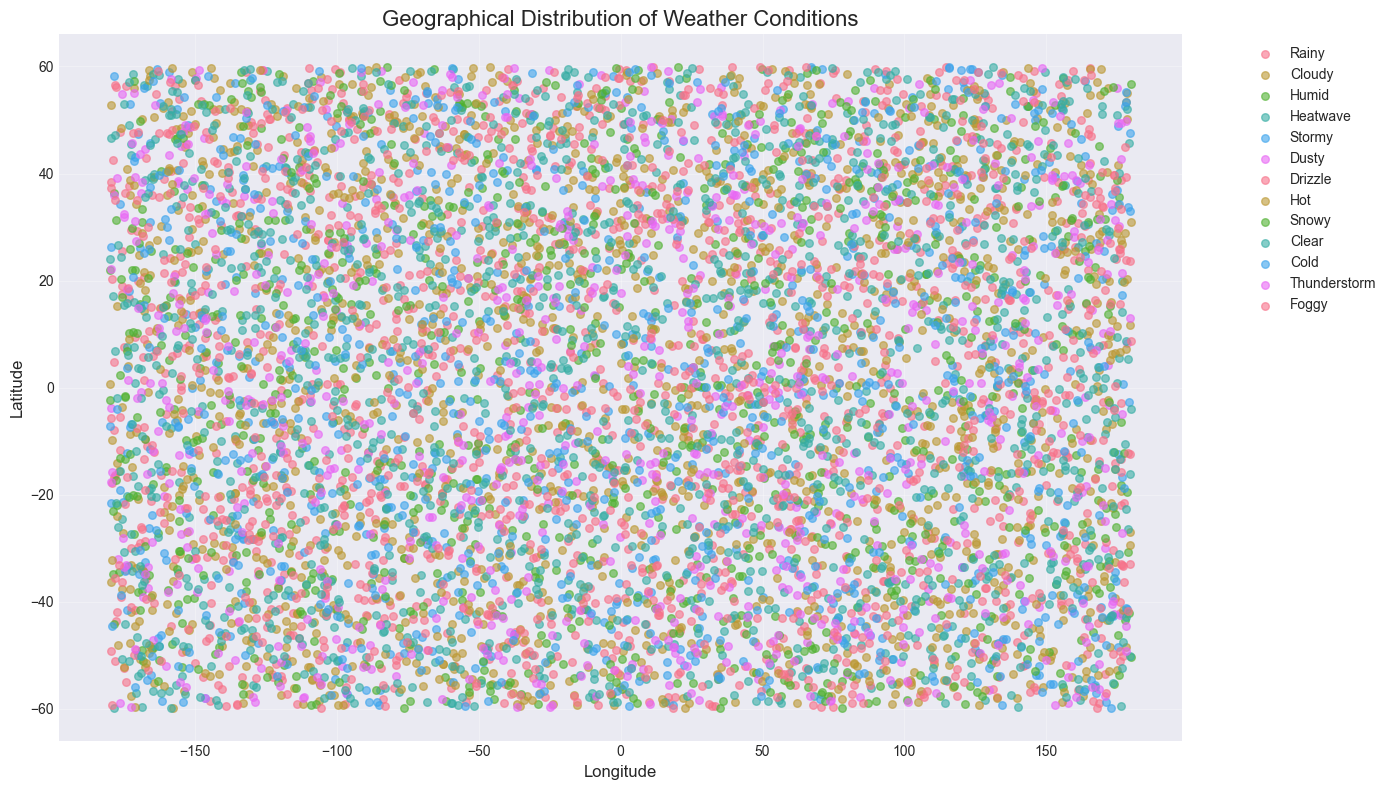

In [14]:
plt.figure(figsize=(14, 8))
unique_classes = df['Weather_Class'].unique()

for i, weather_class in enumerate(unique_classes):
    subset = df[df['Weather_Class'] == weather_class]
    plt.scatter(subset['Longitude'], subset['Latitude'], 
                alpha=0.6, s=30, label=weather_class)

plt.title('Geographical Distribution of Weather Conditions', fontsize=16)
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Distribution of Pressure_hPa - histogram**

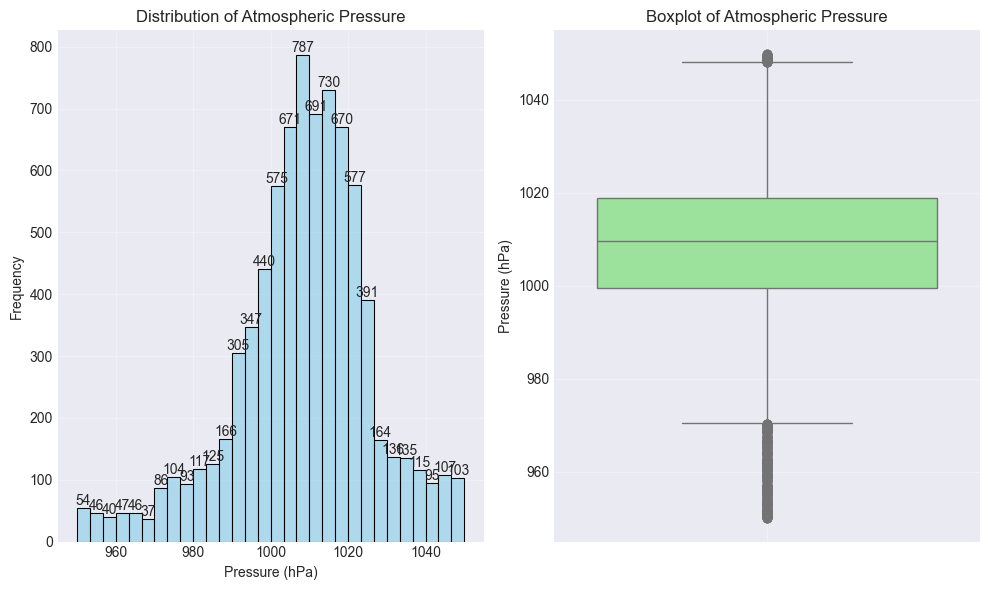

In [15]:
#histogram
plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
ax=sns.histplot(df['Pressure_hPa'], bins=30, color='skyblue', edgecolor='black', alpha=0.6)
for bar in ax.containers:
    ax.bar_label(bar)
plt.title('Distribution of Atmospheric Pressure')
plt.xlabel('Pressure (hPa)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

#boxplot
plt.subplot(1,2,2)
sns.boxplot(y=df['Pressure_hPa'], color='lightgreen')
plt.title('Boxplot of Atmospheric Pressure')
plt.ylabel('Pressure (hPa)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
print(f"\nPressure Statistics:")
print(f"  Mean: {df['Pressure_hPa'].mean():.2f} hPa")
print(f"  Median: {df['Pressure_hPa'].median():.2f} hPa")
print(f"  Std Dev: {df['Pressure_hPa'].std():.2f} hPa")
print(f"  Min: {df['Pressure_hPa'].min():.2f} hPa")
print(f"  Max: {df['Pressure_hPa'].max():.2f} hPa")
print(f"  Range: {df['Pressure_hPa'].max() - df['Pressure_hPa'].min():.2f} hPa")


Pressure Statistics:
  Mean: 1008.37 hPa
  Median: 1009.57 hPa
  Std Dev: 17.59 hPa
  Min: 950.00 hPa
  Max: 1049.94 hPa
  Range: 99.94 hPa


**Top 5 locations with highest average Precipitation_mm**

In [17]:
location_precip = df.groupby(['Latitude', 'Longitude'])['Precipitation_mm'].mean().reset_index()
top_5_location = location_precip.sort_values(by='Precipitation_mm', ascending=False)

print("Rank | Latitude   | Longitude  | Avg Precipitation (mm)")
print("-" * 55)

for i, (idx,row) in enumerate(top_5_location.iterrows(),1):
    print(f'{i:4} | {row["Latitude"]:9.4f} | {row["Longitude"]:9.4f} | {row["Precipitation_mm"]:20.2f}')

Rank | Latitude   | Longitude  | Avg Precipitation (mm)
-------------------------------------------------------
   1 |   10.8420 |  157.0080 |                80.00
   2 |    8.6993 | -114.1264 |                80.00
   3 |  -25.1609 |  156.1394 |                80.00
   4 |   -5.2457 |  -80.5938 |                80.00
   5 |  -35.9662 |   26.1671 |                80.00
   6 |  -58.7383 |  170.9540 |                80.00
   7 |  -13.1112 | -131.4409 |                80.00
   8 |  -27.9502 |  114.1427 |                80.00
   9 |  -53.4019 |   85.6394 |                80.00
  10 |   39.9770 |  -61.4937 |                80.00
  11 |  -12.1131 |  -22.4651 |                80.00
  12 |  -40.3423 | -106.1467 |                76.21
  13 |  -36.9519 |  -50.5940 |                75.07
  14 |  -56.0593 |   51.3255 |                72.24
  15 |  -48.6279 |   -8.8077 |                72.10
  16 |   -2.7190 |   37.5179 |                70.91
  17 |  -47.7153 |  133.0356 |                70.31
  18

**Average Temperature by Weather_Class and binned Wind_Speed**

In [18]:
df['Wind_Speed_Bin'] = pd.cut(df['Wind_Speed_mps'], 
                              bins=np.arange(0, df['Wind_Speed_mps'].max() + 10, 10),
                              right=False)

# Create pivot table
pivot_table = pd.pivot_table(df, 
                            values='Temperature_C', 
                            index='Weather_Class', 
                            columns='Wind_Speed_Bin', 
                            aggfunc='mean',
                            fill_value=None)
print("\nAverage Temperature (°C) by Weather Class and Wind Speed Bin:")
print(pivot_table.round(1).to_string())


Average Temperature (°C) by Weather Class and Wind Speed Bin:
Wind_Speed_Bin  [0.0, 10.0)  [10.0, 20.0)  [20.0, 30.0)  [30.0, 40.0)
Weather_Class                                                        
Clear                  12.9          10.7          13.6          13.1
Cloudy                 15.0          12.6          14.2          13.5
Cold                  -15.2         -14.8         -15.4           NaN
Drizzle                19.1          13.8          12.9          14.6
Dusty                  13.3          13.7          14.7           NaN
Foggy                   8.1           NaN           NaN           NaN
Heatwave               41.9          40.6          42.2          41.3
Hot                    38.6          40.8          39.2          37.3
Humid                  30.3          27.6          27.6          30.0
Rainy                  15.5          13.3          14.4          15.0
Snowy                 -11.6         -11.0         -17.8           NaN
Stormy                  NaN

C:\Users\rakib\AppData\Local\Temp\ipykernel_8700\2206388940.py:6: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot_table = pd.pivot_table(df,




Generating heatmap visualization...


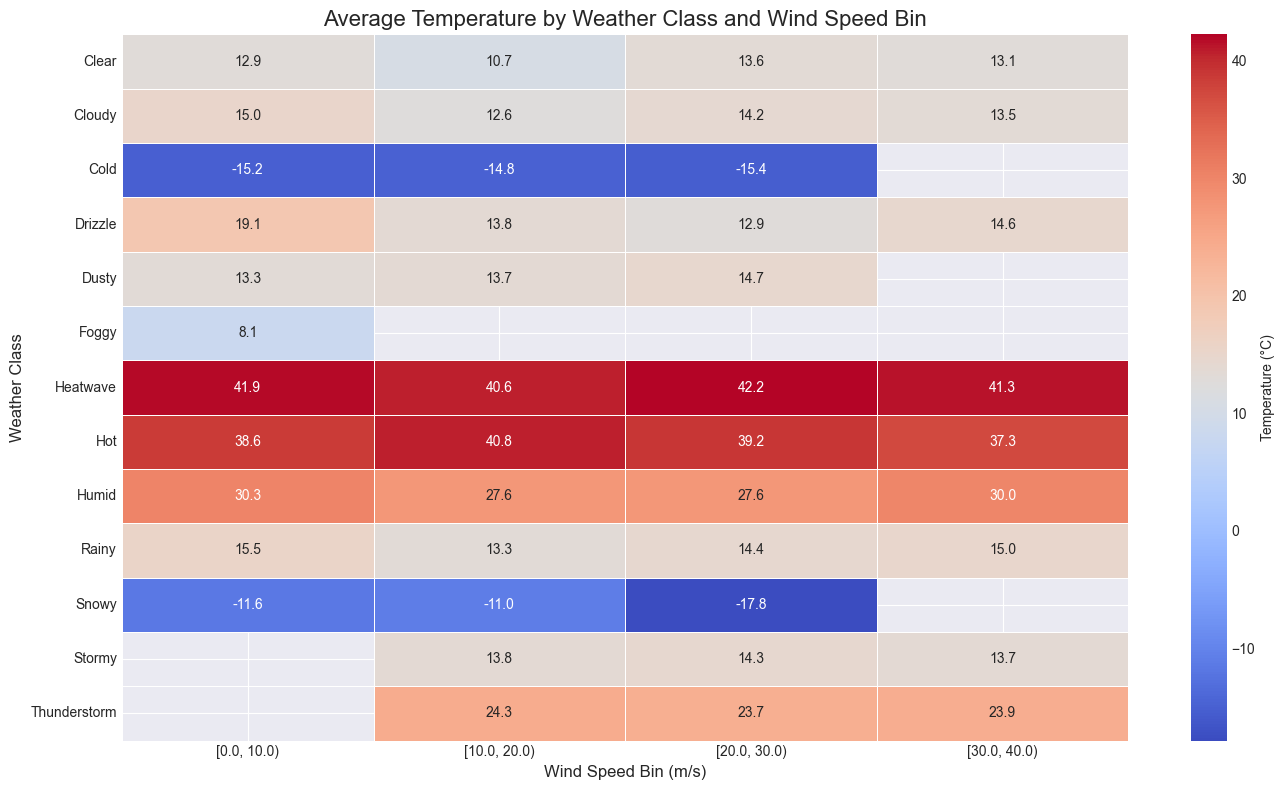

In [19]:
print("\n\nGenerating heatmap visualization...")

plt.figure(figsize=(14, 8))
sns.heatmap(pivot_table, annot=True, fmt='.1f', cmap='coolwarm', 
            cbar_kws={'label': 'Temperature (°C)'}, linewidths=0.5)
plt.title('Average Temperature by Weather Class and Wind Speed Bin', fontsize=16)
plt.xlabel('Wind Speed Bin (m/s)', fontsize=12)
plt.ylabel('Weather Class', fontsize=12)
plt.tight_layout()
plt.show()

**Compute the covariance matrix for numerical features**

In [20]:
from scipy import stats

In [21]:
numerical_features = ['Temperature_C', 'Feels_Like_C', 'Humidity_Percent', 'Dew_Point_C', 
                      'Pressure_hPa', 'Wind_Speed_mps', 'Precipitation_mm', 
                      'Cloud_Cover_Percent', 'Visibility_km', 'UV_Index']
existing_features = [feat for feat in numerical_features if feat in df.columns]
cov_matrix = df[existing_features].cov()

print("Covariance Matrix (showing first 5x5 for readability):")
print("=" * 70)
print(cov_matrix.iloc[:5, :5].to_string(float_format=lambda x: f'{x:.2f}'))

print(f"\nFull matrix shape: {cov_matrix.shape}")

mask = np.triu(np.ones(cov_matrix.shape), k=1).astype(bool)
cov_values = cov_matrix.where(mask).stack()
top_positive = cov_values.nlargest(5)

print("\nTop 5 Positive Relationships:")
for (var1, var2), value in top_positive.items():
    print(f"  {var1:20} & {var2:20}: {value:10.2f}")

top_negative = cov_values.nsmallest(5)
print("\nTop 5 Negative Relationships:")
for (var1, var2), value in top_negative.items():
    print(f"  {var1:20} & {var2:20}: {value:10.2f}")

Covariance Matrix (showing first 5x5 for readability):
                  Temperature_C  Feels_Like_C  Humidity_Percent  Dew_Point_C  Pressure_hPa
Temperature_C            223.16        233.08            -48.68       115.26        -15.68
Feels_Like_C             233.08        367.42            -45.12       147.18          2.08
Humidity_Percent         -48.68        -45.12            651.57        96.21       -153.73
Dew_Point_C              115.26        147.18             96.21       146.82        -13.60
Pressure_hPa             -15.68          2.08           -153.73       -13.60        309.50

Full matrix shape: (10, 10)

Top 5 Positive Relationships:
  Humidity_Percent     & Cloud_Cover_Percent :     516.46
  Temperature_C        & Feels_Like_C        :     233.08
  Feels_Like_C         & Dew_Point_C         :     147.18
  Feels_Like_C         & Wind_Speed_mps      :     122.07
  Precipitation_mm     & Cloud_Cover_Percent :     115.75

Top 5 Negative Relationships:
  Pressure_hPa    

**Plot a boxplot of UV_Index grouped by Weather_Class**

C:\Users\rakib\AppData\Local\Temp\ipykernel_8700\1661916789.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Weather_Class', y='UV_Index', data=df, palette='Set2')


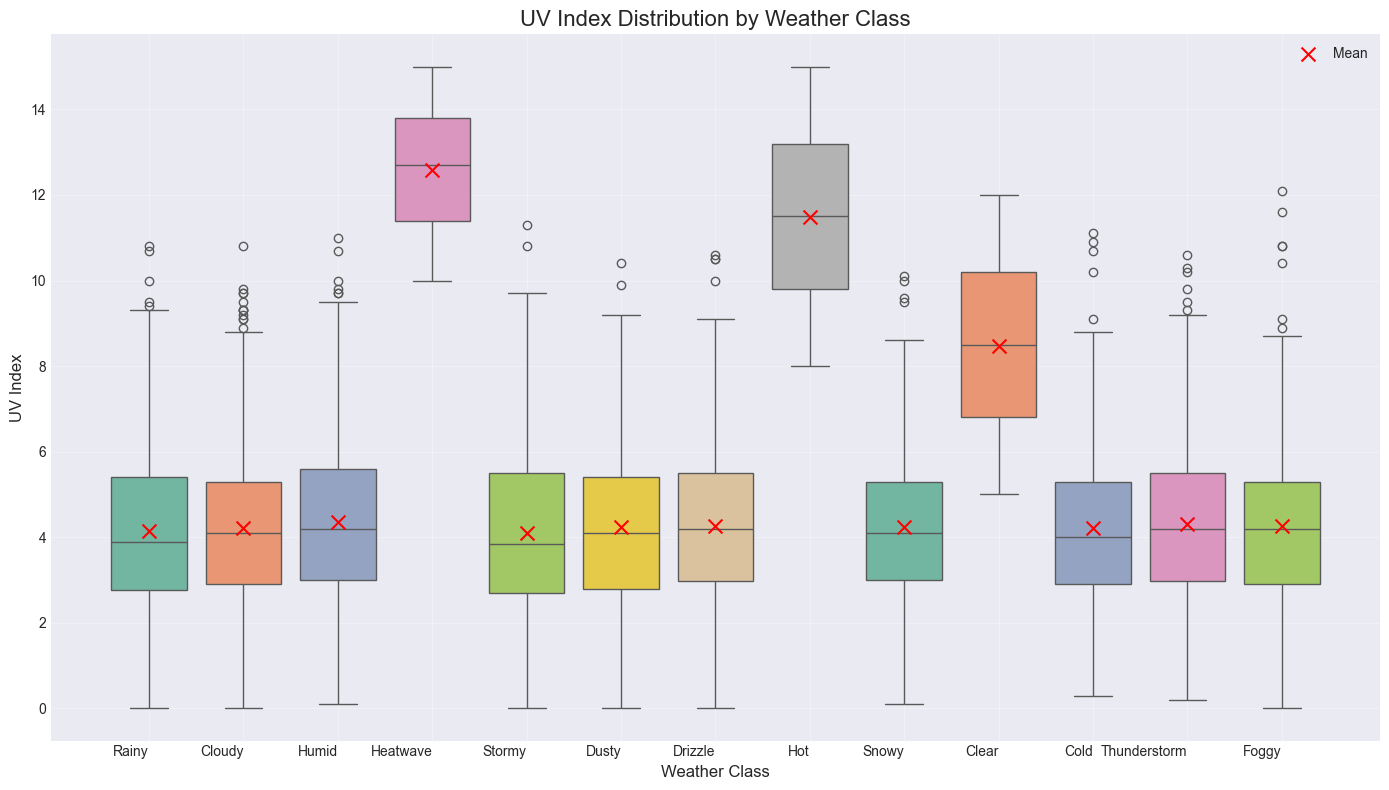


UV Index Statistics by Weather Class:
Weather Class        Mean       Median     Std Dev    Min        Max       
----------------------------------------------------------------------
Clear                      8.48       8.50       2.01       5.00      12.00
Cloudy                     4.21       4.10       1.79       0.00      10.80
Cold                       4.23       4.00       1.87       0.30      11.10
Drizzle                    4.26       4.20       1.83       0.00      10.60
Dusty                      4.25       4.10       1.88       0.00      10.40
Foggy                      4.25       4.20       1.86       0.00      12.10
Heatwave                  12.58      12.70       1.41      10.00      15.00
Hot                       11.49      11.50       2.01       8.00      15.00
Humid                      4.37       4.20       1.90       0.10      11.00
Rainy                      4.15       3.90       1.87       0.00      10.80
Snowy                      4.25       4.10       1.77 

In [22]:
plt.figure(figsize=(14, 8))
sns.boxplot(x='Weather_Class', y='UV_Index', data=df, palette='Set2')
plt.title('UV Index Distribution by Weather Class', fontsize=16)
plt.xlabel('Weather Class', fontsize=12)
plt.ylabel('UV Index', fontsize=12)
plt.xticks(rotation=0, ha='right')
plt.grid(True, alpha=0.3)

uv_means = df.groupby('Weather_Class')['UV_Index'].mean()
for i, weather_class in enumerate(df['Weather_Class'].unique()):
    plt.scatter(i, uv_means[weather_class], color='red', s=100, marker='x', zorder=5, label='Mean' if i == 0 else "")

plt.legend()
plt.tight_layout()
plt.show()

# Statistical summary by weather class
print("\nUV Index Statistics by Weather Class:")
print("=" * 70)
print(f"{'Weather Class':20} {'Mean':10} {'Median':10} {'Std Dev':10} {'Min':10} {'Max':10}")
print("-" * 70)

for weather_class in sorted(df['Weather_Class'].unique()):
    subset = df[df['Weather_Class'] == weather_class]['UV_Index']
    print(f"{weather_class:20} {subset.mean():10.2f} {subset.median():10.2f} {subset.std():10.2f} {subset.min():10.2f} {subset.max():10.2f}")



**Calculate percentage of rows where Cloud_Cover_Percent > 80% and Weather_Class is 'Rainy'**

In [23]:
condition_met = df[(df['Cloud_Cover_Percent'] > 80) & (df['Weather_Class'] == 'Rainy')]
total_rainy = len(df[df['Weather_Class'] == 'Rainy'])
total_rows = len(df)

percentage = (len(condition_met) / total_rainy) * 100
overall_percentage = (len(condition_met) / total_rows) * 100

print(f"Total rows where Cloud_Cover_Percent > 80% AND Weather_Class = 'Rainy': {len(condition_met)}")
print(f"Total 'Rainy' rows in dataset: {total_rainy}")
print(f"Percentage of 'Rainy' rows with >80% cloud cover: {percentage:.2f}%")
print(f"Percentage of ALL rows meeting both conditions: {overall_percentage:.2f}%")

if len(condition_met) > 0:
    print(f"\nStatistics for rows with >80% cloud cover and Rainy weather:")
    print(f"  Average Temperature: {condition_met['Temperature_C'].mean():.2f}°C")
    print(f"  Average Humidity: {condition_met['Humidity_Percent'].mean():.2f}%")
    print(f"  Average Precipitation: {condition_met['Precipitation_mm'].mean():.2f} mm")
    print(f"  Average Wind Speed: {condition_met['Wind_Speed_mps'].mean():.2f} m/s")
    
    # Compare with overall Rainy statistics
    all_rainy = df[df['Weather_Class'] == 'Rainy']
    print(f"\nComparison with ALL Rainy rows:")
    print(f"  {'Metric':25} {'Condition Met':15} {'All Rainy':15} {'Difference':15}")
    print("-" * 70)
    metrics = ['Temperature_C', 'Humidity_Percent', 'Precipitation_mm', 'Wind_Speed_mps']
    for metric in metrics:
        cond_mean = condition_met[metric].mean()
        all_mean = all_rainy[metric].mean()
        diff = cond_mean - all_mean
        print(f"  {metric:25} {cond_mean:15.2f} {all_mean:15.2f} {diff:15.2f}")



Total rows where Cloud_Cover_Percent > 80% AND Weather_Class = 'Rainy': 798
Total 'Rainy' rows in dataset: 800
Percentage of 'Rainy' rows with >80% cloud cover: 99.75%
Percentage of ALL rows meeting both conditions: 9.98%

Statistics for rows with >80% cloud cover and Rainy weather:
  Average Temperature: 13.96°C
  Average Humidity: 87.55%
  Average Precipitation: 12.84 mm
  Average Wind Speed: 38.50 m/s

Comparison with ALL Rainy rows:
  Metric                    Condition Met   All Rainy       Difference     
----------------------------------------------------------------------
  Temperature_C                       13.96           13.95            0.01
  Humidity_Percent                    87.55           87.56           -0.01
  Precipitation_mm                    12.84           12.83            0.02
  Wind_Speed_mps                      38.50           38.51           -0.00


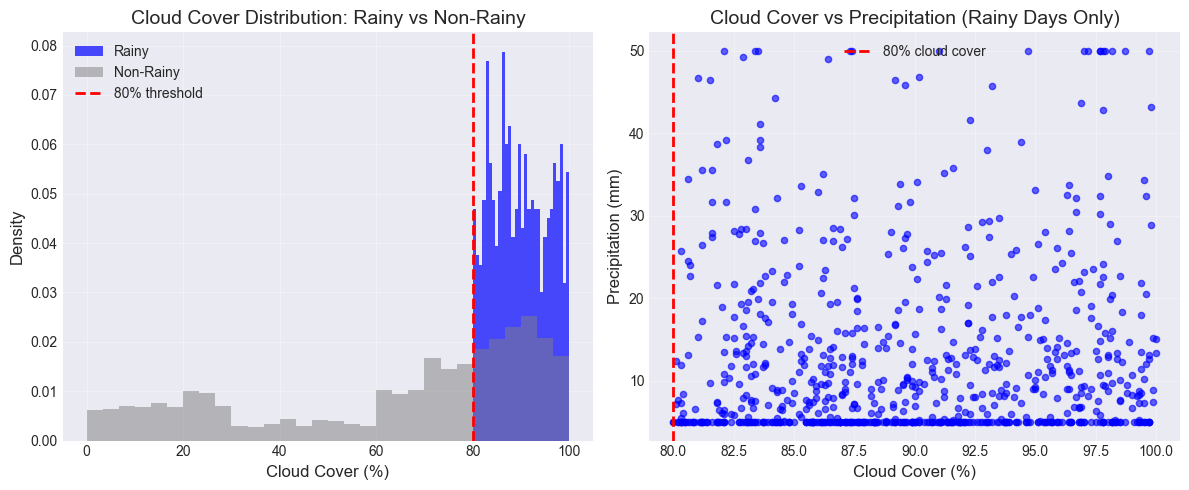

In [24]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
rainy_cloud = df[df['Weather_Class'] == 'Rainy']['Cloud_Cover_Percent']
non_rainy_cloud = df[df['Weather_Class'] != 'Rainy']['Cloud_Cover_Percent']

plt.hist(rainy_cloud, bins=30, alpha=0.7, color='blue', label='Rainy', density=True)
plt.hist(non_rainy_cloud, bins=30, alpha=0.5, color='gray', label='Non-Rainy', density=True)
plt.axvline(80, color='red', linestyle='--', linewidth=2, label='80% threshold')
plt.title('Cloud Cover Distribution: Rainy vs Non-Rainy', fontsize=14)
plt.xlabel('Cloud Cover (%)', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
rainy_data = df[df['Weather_Class'] == 'Rainy']
plt.scatter(rainy_data['Cloud_Cover_Percent'], rainy_data['Precipitation_mm'], 
            alpha=0.6, s=20, color='blue')
plt.axvline(80, color='red', linestyle='--', linewidth=2, label='80% cloud cover')
plt.title('Cloud Cover vs Precipitation (Rainy Days Only)', fontsize=14)
plt.xlabel('Cloud Cover (%)', fontsize=12)
plt.ylabel('Precipitation (mm)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# **Advanced Statistical Analysis**

In [25]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy import stats
from scipy.stats import f_oneway
import statsmodels.api as sm
from statsmodels.formula.api import ols
import warnings
warnings.filterwarnings('ignore')

**PCA (Principal Component Analysis)**

In [26]:
numerical_features = ['Temperature_C', 'Feels_Like_C', 'Humidity_Percent', 
                      'Dew_Point_C', 'Pressure_hPa', 'Wind_Speed_mps', 
                      'Precipitation_mm', 'Cloud_Cover_Percent', 
                      'Visibility_km', 'UV_Index']
existing_features = [feat for feat in numerical_features if feat in df.columns]
X = df[existing_features]
print(f"Original number of features: {len(existing_features)}")
print("Features included in PCA:")
for i, feat in enumerate(existing_features, 1):
    print(f"  {i:2}. {feat}")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"\nPCA Results:")
print("-" * 40)
print(f"Total variance explained by all components: {sum(explained_variance)*100:.2f}%")
print(f"Number of components needed for 95% variance: {n_components_95}")
print(f"\nVariance explained by first {n_components_95} components: {cumulative_variance[n_components_95-1]*100:.2f}%")

print("\nExplained Variance by Component:")
print("-" * 50)
print(f"{'Component':10} {'Variance %':15} {'Cumulative %':15}")
print("-" * 50)
for i, (var, cum_var) in enumerate(zip(explained_variance, cumulative_variance), 1):
    print(f"PC{i:<9} {var*100:14.2f}% {cum_var*100:14.2f}%")
    if cum_var >= 0.95:
        break

Original number of features: 10
Features included in PCA:
   1. Temperature_C
   2. Feels_Like_C
   3. Humidity_Percent
   4. Dew_Point_C
   5. Pressure_hPa
   6. Wind_Speed_mps
   7. Precipitation_mm
   8. Cloud_Cover_Percent
   9. Visibility_km
  10. UV_Index

PCA Results:
----------------------------------------
Total variance explained by all components: 100.00%
Number of components needed for 95% variance: 8

Variance explained by first 8 components: 96.67%

Explained Variance by Component:
--------------------------------------------------
Component  Variance %      Cumulative %   
--------------------------------------------------
PC1                  31.36%          31.36%
PC2                  26.14%          57.50%
PC3                  11.50%          69.01%
PC4                  10.31%          79.32%
PC5                   6.01%          85.33%
PC6                   5.01%          90.33%
PC7                   4.02%          94.35%
PC8                   2.32%          96.67%


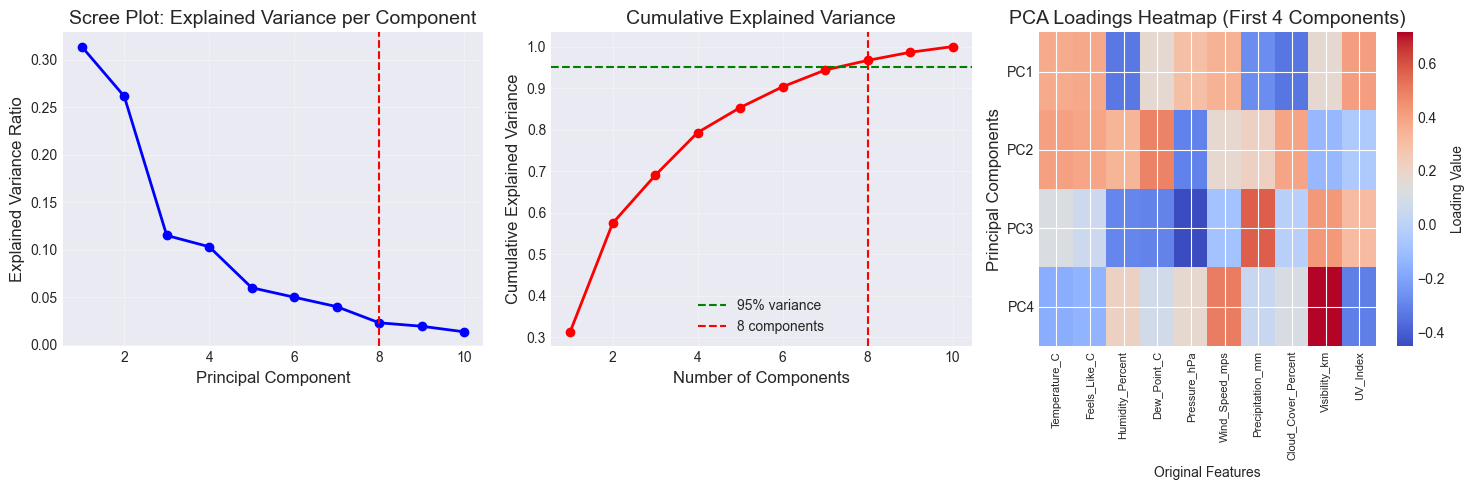

In [27]:
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.plot(range(1, len(explained_variance) + 1), explained_variance, 'bo-', linewidth=2)
plt.title('Scree Plot: Explained Variance per Component', fontsize=14)
plt.xlabel('Principal Component', fontsize=12)
plt.ylabel('Explained Variance Ratio', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axvline(x=n_components_95, color='r', linestyle='--', label=f'{n_components_95} components')

plt.subplot(1, 3, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'ro-', linewidth=2)
plt.axhline(y=0.95, color='g', linestyle='--', label='95% variance')
plt.axvline(x=n_components_95, color='r', linestyle='--', label=f'{n_components_95} components')
plt.title('Cumulative Explained Variance', fontsize=14)
plt.xlabel('Number of Components', fontsize=12)
plt.ylabel('Cumulative Explained Variance', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.subplot(1, 3, 3)
loadings = pca.components_[:4, :]  # First 4 components
plt.imshow(loadings, cmap='coolwarm', aspect='auto')
plt.colorbar(label='Loading Value')
plt.title('PCA Loadings Heatmap (First 4 Components)', fontsize=14)
plt.xlabel('Original Features', fontsize=10)
plt.ylabel('Principal Components', fontsize=12)
plt.yticks(range(4), [f'PC{i+1}' for i in range(4)])
plt.xticks(range(len(existing_features)), existing_features, rotation=90, fontsize=8)

plt.tight_layout()
plt.show()

**ANOVA for Precipitation across Weather_Class categories**

In [28]:
weather_class = df['Weather_Class'].unique()
print(f"Number of weather classes: {len(weather_class)}")

precipitation_groups = [df[df['Weather_Class'] == wc]['Precipitation_mm'].values for wc in weather_class]
f_stat, p_value = f_oneway(*precipitation_groups)

f_stat, p_value = f_oneway(*precipitation_groups)

print(f"\nANOVA Results:")
print(f"  F-statistic: {f_stat:.4f}")
print(f"  P-value: {p_value:.10f}")

alpha = 0.05
if p_value < alpha:
    print(f"\nConclusion: REJECT null hypothesis (p-value < {alpha})")
    print("  There is a statistically significant difference in mean precipitation")
    print("  across different weather classes.")
else:
    print(f"\nConclusion: FAIL TO REJECT null hypothesis (p-value >= {alpha})")
    print("  There is NO statistically significant difference in mean precipitation")
    print("  across different weather classes.")

print("\nPrecipitation Statistics by Weather Class:")
print("=" * 90)
print(f"{'Weather Class':20} {'Count':10} {'Mean (mm)':12} {'Std Dev':12} {'Min':10} {'Max':10}")
print("-" * 90)

stats_by_class = {}
for wc in sorted(weather_class):
    subset = df[df['Weather_Class'] == wc]['Precipitation_mm']
    stats_by_class[wc] = {
        'mean': subset.mean(),
        'std': subset.std(),
        'count': len(subset),
        'min': subset.min(),
        'max': subset.max()
    }
    print(f"{wc:20} {len(subset):10} {subset.mean():12.2f} {subset.std():12.2f} {subset.min():10.2f} {subset.max():10.2f}")

Number of weather classes: 13

ANOVA Results:
  F-statistic: 731.3796
  P-value: 0.0000000000

Conclusion: REJECT null hypothesis (p-value < 0.05)
  There is a statistically significant difference in mean precipitation
  across different weather classes.

Precipitation Statistics by Weather Class:
Weather Class        Count      Mean (mm)    Std Dev      Min        Max       
------------------------------------------------------------------------------------------
Clear                       960         0.00         0.00       0.00       0.00
Cloudy                     1200         0.00         0.00       0.00       0.00
Cold                        400         0.53         1.31       0.00       9.56
Drizzle                     560         1.53         1.26       0.50       5.00
Dusty                       400         0.00         0.00       0.00       0.00
Foggy                       480         0.10         0.36       0.00       4.26
Heatwave                    560         0.61      

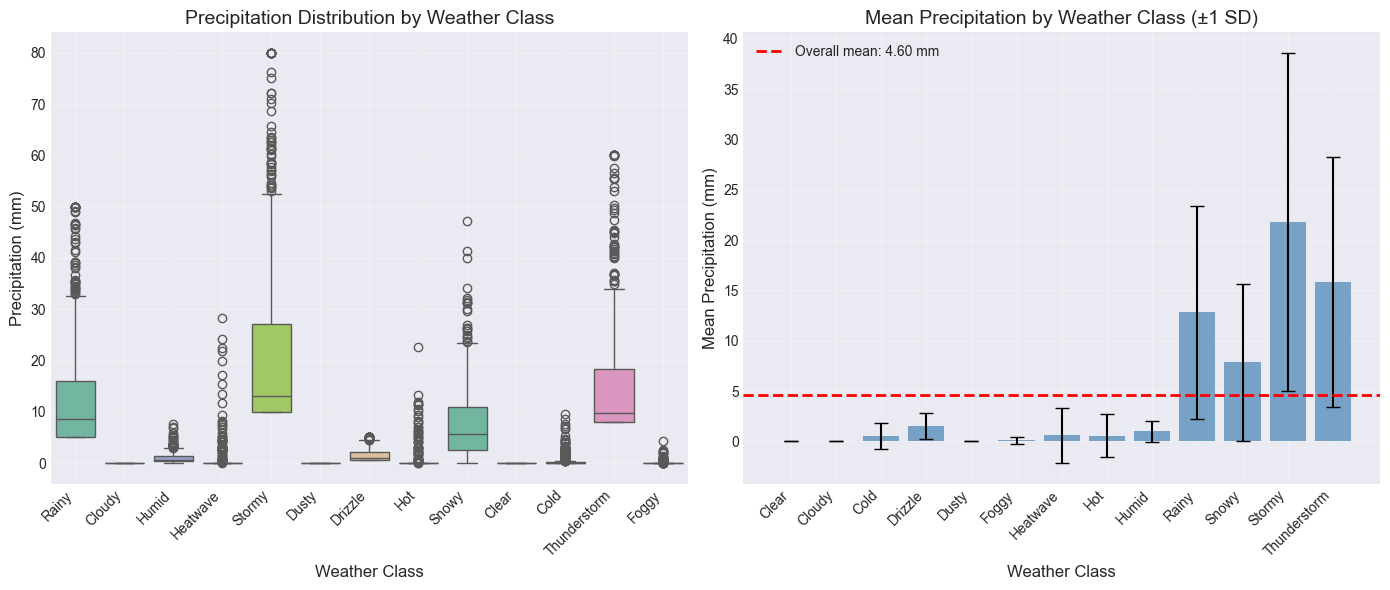

In [29]:
plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
sns.boxplot(x='Weather_Class', y='Precipitation_mm', data=df, palette='Set2')
plt.title('Precipitation Distribution by Weather Class', fontsize=14)
plt.xlabel('Weather Class', fontsize=12)
plt.ylabel('Precipitation (mm)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
means = [stats_by_class[wc]['mean'] for wc in sorted(stats_by_class.keys())]
stds = [stats_by_class[wc]['std'] for wc in sorted(stats_by_class.keys())]
x_pos = np.arange(len(means))

plt.bar(x_pos, means, yerr=stds, capsize=5, alpha=0.7, color='steelblue')
plt.axhline(y=df['Precipitation_mm'].mean(), color='red', linestyle='--', 
            linewidth=2, label=f'Overall mean: {df["Precipitation_mm"].mean():.2f} mm')
plt.title('Mean Precipitation by Weather Class (±1 SD)', fontsize=14)
plt.xlabel('Weather Class', fontsize=12)
plt.ylabel('Mean Precipitation (mm)', fontsize=12)
plt.xticks(x_pos, sorted(stats_by_class.keys()), rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
if p_value < alpha and len(weather_class) > 2:
    print("\nPost-hoc Analysis (Tukey's HSD):")
    print("Performing pairwise comparisons...")
    try:
        from statsmodels.stats.multicomp import pairwise_tukeyhsd
        
        tukey = pairwise_tukeyhsd(
            endog=df['Precipitation_mm'],
            groups=df['Weather_Class'],
            alpha=0.05
        )
        
        print("\nPairwise Comparisons (reject null if p < 0.05):")
        print(tukey.summary())
    except Exception as e:
        print(f"Could not perform Tukey's HSD: {e}")


Post-hoc Analysis (Tukey's HSD):
Performing pairwise comparisons...

Pairwise Comparisons (reject null if p < 0.05):
    Multiple Comparison of Means - Tukey HSD, FWER=0.05     
 group1     group2    meandiff p-adj   lower   upper  reject
------------------------------------------------------------
   Clear       Cloudy      0.0    1.0 -0.9799  0.9799  False
   Clear         Cold   0.5285 0.9862 -0.8182  1.8753  False
   Clear      Drizzle   1.5267 0.0019  0.3234    2.73   True
   Clear        Dusty      0.0    1.0 -1.3467  1.3467  False
   Clear        Foggy   0.0995    1.0 -1.1655  1.3645  False
   Clear     Heatwave   0.6127 0.9001 -0.5906   1.816  False
   Clear          Hot   0.5433  0.971 -0.7217  1.8084  False
   Clear        Humid   1.0016 0.1316 -0.1141  2.1172  False
   Clear        Rainy  12.8252    0.0 11.7419 13.9086   True
   Clear        Snowy   7.8438    0.0  6.3831  9.3045   True
   Clear       Stormy  21.7969    0.0 20.6421 22.9517   True
   Clear Thunderstorm  15.83

# **Applying Machine Learning**

In [31]:
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor, VotingClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVC, SVR
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
from sklearn.feature_selection import RFE
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import warnings
import xgboost as xgb

In [32]:
existing_numerical = [feat for feat in numerical_features if feat in df.columns]

#encoding the target variable
le=LabelEncoder()
df['Weather_Class_encoded'] = le.fit_transform(df['Weather_Class'])

#create binary target for Rainy vs Non-Rainy
df['Is_Rainy'] = (df['Weather_Class'] == 'Rainy').astype(int)

X = df[existing_numerical]
y = df['Weather_Class_encoded']
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)

In [33]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [34]:
lr_model = LogisticRegression(max_iter=1000, random_state=42, multi_class='ovr')
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)
y_pred_proba_lr = lr_model.predict_proba(X_test_scaled)

In [35]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print(f"Test set size: {len(X_test)} samples")
print(f"Number of features: {len(existing_numerical)}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

Logistic Regression Accuracy: 0.9231
Test set size: 1600 samples
Number of features: 10

Classification Report:
              precision    recall  f1-score   support

       Clear       0.99      0.98      0.99       192
      Cloudy       0.86      0.93      0.90       240
        Cold       1.00      1.00      1.00        80
     Drizzle       0.83      0.56      0.67       112
       Dusty       0.99      1.00      0.99        80
       Foggy       1.00      1.00      1.00        96
    Heatwave       0.87      0.92      0.90       112
         Hot       0.91      0.82      0.86        96
       Humid       0.97      1.00      0.98       144
       Rainy       0.92      0.89      0.91       160
       Snowy       0.98      1.00      0.99        64
      Stormy       0.86      0.98      0.92       128
Thunderstorm       0.90      0.90      0.90        96

    accuracy                           0.92      1600
   macro avg       0.93      0.92      0.92      1600
weighted avg       0.9

In [36]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

y_pred_rf = rf_classifier.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print(f"Random Forest Accuracy: {accuracy_rf:.4f}")
print(f"Improvement over Logistic Regression: {accuracy_rf - accuracy_lr:.4f}")

Random Forest Accuracy: 0.9894
Improvement over Logistic Regression: 0.0663


In [37]:
feature_importance = pd.DataFrame({
    'feature': existing_numerical,
    'importance': rf_classifier.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 10 Most Important Features:")
print(feature_importance.head(10).to_string(index=False))


Top 10 Most Important Features:
            feature  importance
   Precipitation_mm    0.161274
     Wind_Speed_mps    0.143309
      Temperature_C    0.124956
Cloud_Cover_Percent    0.123383
   Humidity_Percent    0.123314
       Feels_Like_C    0.090839
        Dew_Point_C    0.080071
       Pressure_hPa    0.066774
      Visibility_km    0.044866
           UV_Index    0.041212


In [38]:
precip_features = [f for f in existing_numerical if f != 'Precipitation_mm']
X_precip = df[precip_features]
y_precip = df['Precipitation_mm']

X_train_precip, X_test_precip, y_train_precip, y_test_precip = train_test_split(  X_precip, y_precip, test_size=0.2, random_state=42)



In [39]:
# Train Decision Tree Regressor
dt_regressor = DecisionTreeRegressor(random_state=42, max_depth=5)
dt_regressor.fit(X_train_precip, y_train_precip)

y_pred_precip = dt_regressor.predict(X_test_precip)


mae_dt = mean_absolute_error(y_test_precip, y_pred_precip)
rmse_dt = np.sqrt(mean_squared_error(y_test_precip, y_pred_precip))
r2_dt = r2_score(y_test_precip, y_pred_precip)

print(f"Decision Tree Regressor Results:")
print(f"  Mean Absolute Error (MAE): {mae_dt:.4f} mm")
print(f"  Root Mean Squared Error (RMSE): {rmse_dt:.4f} mm")
print(f"  R-squared: {r2_dt:.4f}")
print(f"  Mean Precipitation in test set: {y_test_precip.mean():.4f} mm")

Decision Tree Regressor Results:
  Mean Absolute Error (MAE): 3.6427 mm
  Root Mean Squared Error (RMSE): 8.0588 mm
  R-squared: 0.4497
  Mean Precipitation in test set: 5.0759 mm


In [40]:
# Baseline model (predicting mean)
y_baseline = np.full_like(y_test_precip, y_train_precip.mean())
mae_baseline = mean_absolute_error(y_test_precip, y_baseline)
print(f"\nBaseline (mean prediction) MAE: {mae_baseline:.4f} mm")
print(f"Improvement over baseline: {(mae_baseline - mae_dt)/mae_baseline*100:.2f}%")


Baseline (mean prediction) MAE: 6.4970 mm
Improvement over baseline: 43.93%


**SVM for Binary Classification (Rainy vs Non-Rainy)**

In [41]:
X_binary = df[existing_numerical]
y_binary = df['Is_Rainy']

X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split( X_binary, y_binary, test_size=0.2, random_state=42, stratify=y_binary)

In [42]:
scaler_bin = StandardScaler()
X_train_bin_scaled = scaler_bin.fit_transform(X_train_bin)
X_test_bin_scaled = scaler_bin.transform(X_test_bin)

In [43]:
param_grid = {
    'C': [0.1, 1, 10, 100],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto']
}

svm_model = SVC(random_state=42)
grid_search = GridSearchCV(svm_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_bin_scaled, y_train_bin)

print(f"Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation accuracy: {grid_search.best_score_:.4f}")

Best parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}
Best cross-validation accuracy: 0.9864


In [44]:
# Test set evaluation
best_svm = grid_search.best_estimator_
y_pred_svm = best_svm.predict(X_test_bin_scaled)
accuracy_svm = accuracy_score(y_test_bin, y_pred_svm)

print(f"\nTest set accuracy: {accuracy_svm:.4f}")
print(f"Number of Rainy samples in test set: {y_test_bin.sum()}/{len(y_test_bin)}")
print(f"Baseline accuracy (predict all non-rainy): {(1 - y_test_bin.mean()):.4f}")


Test set accuracy: 0.9912
Number of Rainy samples in test set: 160/1600
Baseline accuracy (predict all non-rainy): 0.9000


In [45]:
# Cross-validation scores
cv_scores = cross_val_score(best_svm, X_train_bin_scaled, y_train_bin, cv=5)
print(f"\n5-fold CV scores: {cv_scores}")
print(f"Mean CV accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")


5-fold CV scores: [0.9875     0.98515625 0.9828125  0.98515625 0.99140625]
Mean CV accuracy: 0.9864 ± 0.0029


**Gradient Boosting for UV_Index Prediction**

In [46]:
uv_features = [f for f in existing_numerical if f != 'UV_Index']
X_uv = df[uv_features]
y_uv = df['UV_Index']

X_train_uv, X_test_uv, y_train_uv, y_test_uv = train_test_split(X_uv, y_uv, test_size=0.2, random_state=42)

In [47]:
xgb_model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train_uv, y_train_uv)
y_pred_uv = xgb_model.predict(X_test_uv)
model_name = "XGBoost"


rmse_gb = np.sqrt(mean_squared_error(y_test_uv, y_pred_uv))
mae_gb = mean_absolute_error(y_test_uv, y_pred_uv)
r2_gb = r2_score(y_test_uv, y_pred_uv)

print(f"\n{model_name} Results:")
print(f"  RMSE: {rmse_gb:.4f}")
print(f"  MAE: {mae_gb:.4f}")
print(f"  R-squared: {r2_gb:.4f}")


XGBoost Results:
  RMSE: 1.8111
  MAE: 1.4561
  R-squared: 0.6838


**Baseline model (mean prediction)**

In [48]:
y_baseline_uv = np.full_like(y_test_uv, y_train_uv.mean())
rmse_baseline = np.sqrt(mean_squared_error(y_test_uv, y_baseline_uv))

print(f"\nBaseline (mean prediction):")
print(f"  RMSE: {rmse_baseline:.4f}")
print(f"  Improvement: {(rmse_baseline - rmse_gb)/rmse_baseline*100:.2f}%")
print(f"  Mean UV Index: {y_train_uv.mean():.2f}")


Baseline (mean prediction):
  RMSE: 3.2223
  Improvement: 43.80%
  Mean UV Index: 5.78


**Feature Selection using RFE for Humidity Prediction**

In [49]:
humidity_features = [f for f in existing_numerical if f != 'Humidity_Percent']
X_humidity = df[humidity_features]
y_humidity = df['Humidity_Percent']

# Split data
X_train_hum, X_test_hum, y_train_hum, y_test_hum = train_test_split(
    X_humidity, y_humidity, test_size=0.2, random_state=42
)

In [50]:
scaler_hum = StandardScaler()
X_train_hum_scaled = scaler_hum.fit_transform(X_train_hum)
X_test_hum_scaled = scaler_hum.transform(X_test_hum)

In [51]:
from sklearn.linear_model import LinearRegression
lr_humidity = LinearRegression()
rfe = RFE(estimator=lr_humidity, n_features_to_select=5)  # Select top 5 features
rfe.fit(X_train_hum_scaled, y_train_hum)

,estimator,LinearRegression()
,n_features_to_select,5
,step,1
,verbose,0
,importance_getter,'auto'
,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [52]:
selected_features_mask = rfe.support_
selected_features = np.array(humidity_features)[selected_features_mask]

print(f"Selected {rfe.n_features_} features out of {len(humidity_features)}:")
for i, feature in enumerate(selected_features, 1):
    print(f"  {i}. {feature}")

Selected 5 features out of 9:
  1. Temperature_C
  2. Dew_Point_C
  3. Precipitation_mm
  4. Cloud_Cover_Percent
  5. Visibility_km


In [53]:
ranking = rfe.ranking_
feature_ranking = pd.DataFrame({
    'feature': humidity_features,
    'ranking': ranking
}).sort_values('ranking')

print("\nFeature Ranking (1 = selected):")
print(feature_ranking.to_string(index=False))


Feature Ranking (1 = selected):
            feature  ranking
      Temperature_C        1
        Dew_Point_C        1
Cloud_Cover_Percent        1
   Precipitation_mm        1
      Visibility_km        1
       Pressure_hPa        2
       Feels_Like_C        3
     Wind_Speed_mps        4
           UV_Index        5


In [54]:
X_train_selected = X_train_hum_scaled[:, selected_features_mask]
X_test_selected = X_test_hum_scaled[:, selected_features_mask]

lr_selected = LinearRegression()
lr_selected.fit(X_train_selected, y_train_hum)
y_pred_selected = lr_selected.predict(X_test_selected)


In [55]:
lr_full = LinearRegression()
lr_full.fit(X_train_hum_scaled, y_train_hum)
y_pred_full = lr_full.predict(X_test_hum_scaled)

rmse_selected = np.sqrt(mean_squared_error(y_test_hum, y_pred_selected))
rmse_full = np.sqrt(mean_squared_error(y_test_hum, y_pred_full))

print(f"\nModel Performance:")
print(f"  Full model ({len(humidity_features)} features) RMSE: {rmse_full:.4f}")
print(f"  Selected model (5 features) RMSE: {rmse_selected:.4f}")
print(f"  Difference: {rmse_selected - rmse_full:.4f}")



Model Performance:
  Full model (9 features) RMSE: 16.2205
  Selected model (5 features) RMSE: 16.2769
  Difference: 0.0564


**KNN Classifier with Grid Search**

In [56]:
X_train_knn = X_train_scaled
X_test_knn = X_test_scaled

param_grid_knn = {
    'n_neighbors': range(1, 31, 2),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

In [57]:
knn = KNeighborsClassifier()
grid_knn = GridSearchCV(knn, param_grid_knn, cv=5, scoring='accuracy', n_jobs=-1)
grid_knn.fit(X_train_knn, y_train)

print(f"Best parameters: {grid_knn.best_params_}")
print(f"Best cross-validation accuracy: {grid_knn.best_score_:.4f}")

Best parameters: {'metric': 'manhattan', 'n_neighbors': 27, 'weights': 'distance'}
Best cross-validation accuracy: 0.9500


In [58]:
# Test set evaluation
best_knn = grid_knn.best_estimator_
y_pred_knn = best_knn.predict(X_test_knn)
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print(f"\nKNN Test set accuracy: {accuracy_knn:.4f}")
print(f"Optimal k: {grid_knn.best_params_['n_neighbors']}")


KNN Test set accuracy: 0.9494
Optimal k: 27


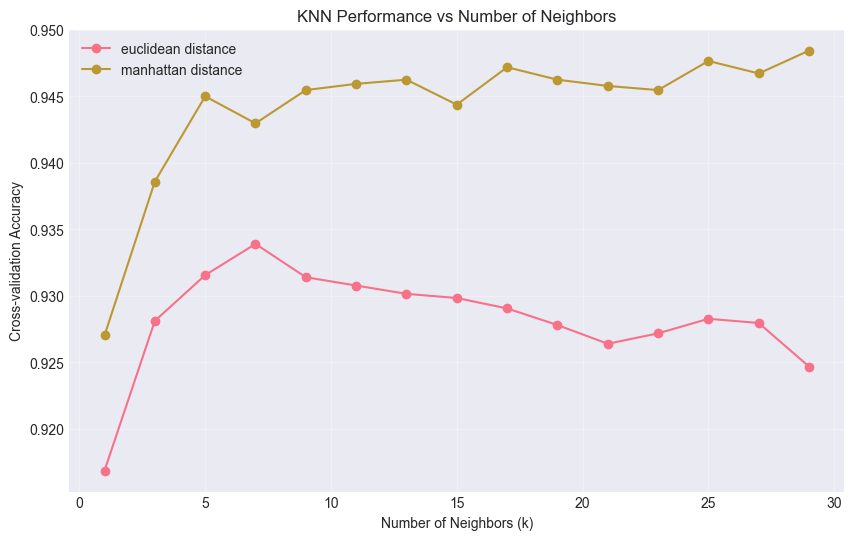

In [59]:
# Visualize k vs accuracy
results_df = pd.DataFrame(grid_knn.cv_results_)
uniform_results = results_df[results_df['param_weights'] == 'uniform']

plt.figure(figsize=(10, 6))
for metric in ['euclidean', 'manhattan']:
    subset = uniform_results[uniform_results['param_metric'] == metric]
    plt.plot(subset['param_n_neighbors'], subset['mean_test_score'], 
             marker='o', label=f'{metric} distance')
    
plt.xlabel('Number of Neighbors (k)')
plt.ylabel('Cross-validation Accuracy')
plt.title('KNN Performance vs Number of Neighbors')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Naive Bayes Classifier with Confusion Matrix Comparison**

In [60]:
nb_model = GaussianNB()
nb_model.fit(X_train_scaled, y_train)
y_pred_nb = nb_model.predict(X_test_scaled)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

print(f"Naive Bayes Accuracy: {accuracy_nb:.4f}")
print(f"Logistic Regression Accuracy: {accuracy_lr:.4f}")
print(f"Difference: {accuracy_nb - accuracy_lr:.4f}")

Naive Bayes Accuracy: 0.9413
Logistic Regression Accuracy: 0.9231
Difference: 0.0181


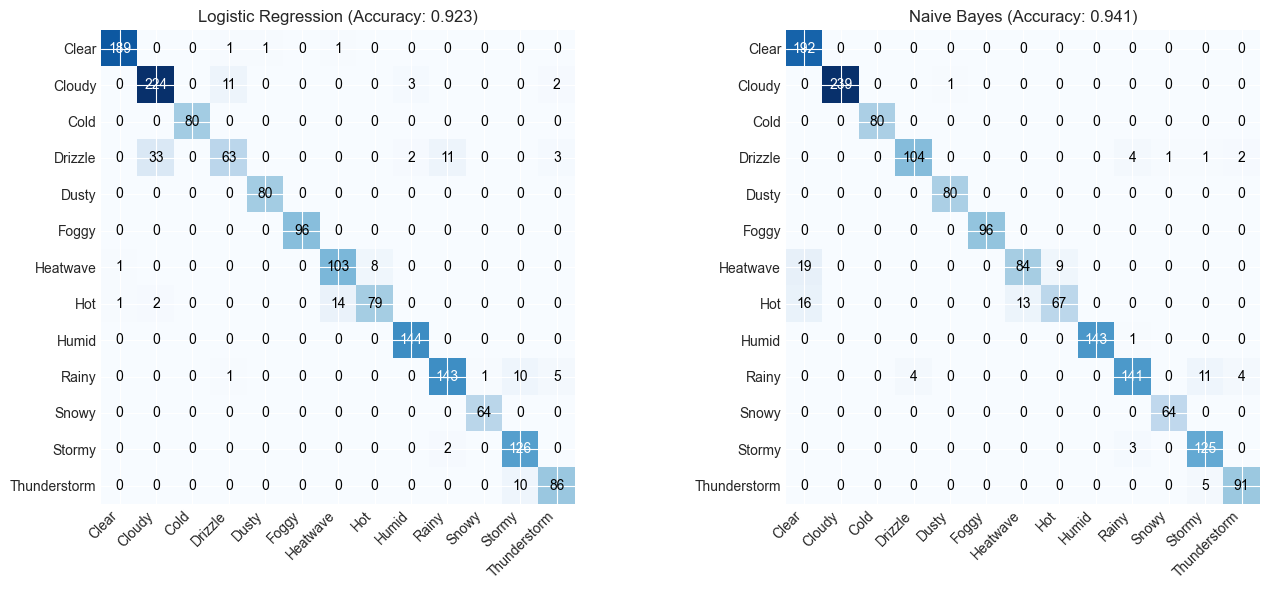

In [61]:
# Confusion matrices
cm_lr = confusion_matrix(y_test, y_pred_lr)
cm_nb = confusion_matrix(y_test, y_pred_nb)

# Visualize confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for idx, (cm, title, ax) in enumerate(zip(
    [cm_lr, cm_nb],
    ['Logistic Regression', 'Naive Bayes'],
    axes
)):
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
    ax.set_title(f'{title} (Accuracy: {accuracy_lr if idx == 0 else accuracy_nb:.3f})')
    ax.set_xticks(np.arange(len(le.classes_)))
    ax.set_yticks(np.arange(len(le.classes_)))
    ax.set_xticklabels(le.classes_, rotation=45, ha='right')
    ax.set_yticklabels(le.classes_)
    
    # Add text annotations
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], 'd'),
                   ha="center", va="center",
                   color="white" if cm[i, j] > thresh else "black")

plt.tight_layout()
plt.show()

**Handle Class Imbalance with SMOTE**

In [62]:
smote_rf_pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])


In [63]:
smote_rf_pipeline.fit(X_train, y_train)
y_pred_smote = smote_rf_pipeline.predict(X_test)
accuracy_smote = accuracy_score(y_test, y_pred_smote)

print(f"\nRandom Forest with SMOTE Accuracy: {accuracy_smote:.4f}")
print(f"Random Forest without SMOTE Accuracy: {accuracy_rf:.4f}")
print(f"Difference: {accuracy_smote - accuracy_rf:.4f}")


Random Forest with SMOTE Accuracy: 0.9900
Random Forest without SMOTE Accuracy: 0.9894
Difference: 0.0006


In [64]:
# Check per-class performance improvement
print("\nPer-class performance comparison:")
cm_smote = confusion_matrix(y_test, y_pred_smote)
cm_rf = confusion_matrix(y_test, y_pred_rf)

for i, class_name in enumerate(le.classes_):
    smote_class_acc = cm_smote[i, i] / cm_smote[i, :].sum() if cm_smote[i, :].sum() > 0 else 0
    rf_class_acc = cm_rf[i, i] / cm_rf[i, :].sum() if cm_rf[i, :].sum() > 0 else 0
    diff = smote_class_acc - rf_class_acc
    if diff != 0:
        print(f"  {class_name:15}: Without={rf_class_acc:.3f}, With SMOTE={smote_class_acc:.3f}, Diff={diff:+.3f}")


Per-class performance comparison:
  Clear          : Without=1.000, With SMOTE=0.995, Diff=-0.005
  Drizzle        : Without=0.964, With SMOTE=0.973, Diff=+0.009
  Heatwave       : Without=0.955, With SMOTE=0.946, Diff=-0.009
  Hot            : Without=0.927, With SMOTE=0.948, Diff=+0.021


In [65]:
# Visualize class distribution after SMOTE
print("\nClass distribution in training set after SMOTE:")
X_resampled, y_resampled = SMOTE(random_state=42).fit_resample(X_train, y_train)
resampled_dist = pd.Series(y_resampled).value_counts().sort_index()
resampled_dist.index = le.inverse_transform(resampled_dist.index)
print(resampled_dist)

print("\n" + "=" * 100)
print("SUMMARY OF ALL MODELS")
print("=" * 100)

summary_data = {
    'Model': ['Logistic Regression', 'Random Forest', 'Decision Tree Regressor', 
              'SVM (binary)', 'Gradient Boosting', 'KNN', 'Naive Bayes', 
              'Random Forest + SMOTE'],
    'Metric': ['Accuracy', 'Accuracy', 'MAE', 'Accuracy', 'RMSE', 'Accuracy', 
               'Accuracy', 'Accuracy'],
    'Value': [accuracy_lr, accuracy_rf, mae_dt, accuracy_svm, rmse_gb, 
              accuracy_knn, accuracy_nb, accuracy_smote],
    'Note': ['Multiclass', 'Multiclass', f'{mae_dt:.4f} mm', 'Rainy vs Non-Rainy', 
             f'{rmse_gb:.4f}', f'k={grid_knn.best_params_["n_neighbors"]}', 
             'Multiclass', 'With oversampling']
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))


Class distribution in training set after SMOTE:
Clear           960
Cloudy          960
Cold            960
Drizzle         960
Dusty           960
Foggy           960
Heatwave        960
Hot             960
Humid           960
Rainy           960
Snowy           960
Stormy          960
Thunderstorm    960
Name: count, dtype: int64

SUMMARY OF ALL MODELS
                  Model   Metric    Value               Note
    Logistic Regression Accuracy 0.923125         Multiclass
          Random Forest Accuracy 0.989375         Multiclass
Decision Tree Regressor      MAE 3.642671          3.6427 mm
           SVM (binary) Accuracy 0.991250 Rainy vs Non-Rainy
      Gradient Boosting     RMSE 1.811105             1.8111
                    KNN Accuracy 0.949375               k=27
            Naive Bayes Accuracy 0.941250         Multiclass
  Random Forest + SMOTE Accuracy 0.990000  With oversampling
